### plan node 점검 

In [1]:
import os, sys

sys.path.append(os.path.abspath(os.path.join(os.path.dirname("utils"), "..")))
from module.utils import *
from module.prompt import *
from module.custom_model import *
from module.base_model import *
from module.tools import *
start_langsmith("final_music")
from typing import TypedDict, Annotated, List, Literal, Tuple
from langgraph.graph.message import add_messages
from langgraph.graph import StateGraph, START, END
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage, ToolMessage
from langgraph.prebuilt import create_react_agent
from langchain_core.tools import tool
from langchain_core.runnables import RunnableLambda, RunnableWithFallbacks

LangSmith 추적을 시작합니다.
[프로젝트명]
final_music


In [2]:
class State(TypedDict):
    question: Annotated[str, "user input question"]  # 사용자 질의 or requeustion 질의
    plan: Annotated[list[str], "get plan_node"]  # llm 생성한 작업 계획서
    messages: Annotated[list, add_messages]  # 작업 수행 후 얻은 데이터
    past_steps: Annotated[list, add_messages]  # 현재 단계에서 수행한 결과
    answer: Annotated[str, " output final answer"]  # 최종 답변 출력
    human_feedback: bool = False
    next_agent: Annotated[str, " use agent"]

In [3]:

def plan_node(state: State) -> State:
    llm = get_gpt()
    prompt = get_prompt_music_planner()
    chain = prompt | llm.with_structured_output(PlanListModel)
    response = chain.invoke({"messages": [state["question"]]})
    return State({"plan": response.steps})

In [4]:
state_graph = StateGraph(State)
state_graph.add_node("plan_node", plan_node)

state_graph.add_edge(START, "plan_node")
state_graph.add_edge('plan_node', END)

cp = get_check_pointer()
graph = state_graph.compile(checkpointer=cp)

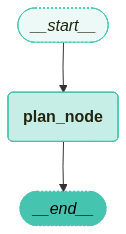

In [5]:
visualize_graph(graph)

In [ ]:
request_template = """ 
    # System :
    You are an AI assistant
    Genie Music users, please create different types of queries
    I'm gonna get you to judge the performance of the llm agent

    # History : 
    {messages}

    # Answer : 
    Please write your answers in an array of short answers
    ['a','b','c'...]

    # Impotant : 
    Answer in Korean
    """
request_prompt = ChatPromptTemplate.from_template(request_template)

In [ ]:
llm = request_prompt| get_gemini() | StrOutputParser()
queries = llm.invoke('질문 10개 생성해줘')
print(queries)
import ast
result = ast.literal_eval(queries)

In [ ]:
config = get_runnable_config(recursion_limit=20, thread_id=get_random_uuid())

for query in result:
    inputs = {"question":query}
    response =  graph.invoke(input=inputs,config=config,stream_mode='values')
    print(response)


In [6]:
config = get_runnable_config(recursion_limit=20, thread_id=get_random_uuid())

query = "내이름은 Kara Nielsen 야 안녕"
inputs = {"question":query}
response =  graph.invoke(input=inputs,config=config,stream_mode='values')
print(response)

{'question': '내이름은 Kara Nielsen 야 안녕', 'plan': ["사용자가 자신의 이름을 'Kara Nielsen'이라고 소개함", '사용자에게 인사로 응답함'], 'messages': [], 'past_steps': []}
